In [164]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3
import bisect
import math

from Runtime_visualizations_combined import tag_total_programs

In [ ]:
def stream_results(filename):
    with open(filename, 'rb') as f:
        while True:
            try:
                # Reads the next object from the stream
                yield pickle.load(f)
            except EOFError:
                # We reached the end of the file
                break

In [ ]:
file = "results/utm15_2_results_len30.pkl"
max_runtime = 100_000
utm_num_runtimes = np.zeros(max_runtime, dtype=int)
max_length = 0

with open(file, "rb") as f:
    counter = 0
    while True:
        try:
            batch = pickle.load(f)
            counter += 1
            for length, steps in batch:
                if length != 30:
                    continue
                utm_num_runtimes[steps] += 1
                if counter % 1_000_000 == 0:
                    print(f"Processed {counter} results, most common runtime: {np.argmax(utm_num_runtimes[:1000])} with {max(utm_num_runtimes[:1000])} programs")
                counter += 1
        except EOFError:
            break

In [ ]:
# save the num runtimes arrays to a file
with open("results/utm15_2_num_length_30_runtimes.pkl", "wb") as f:
    pickle.dump(utm_num_runtimes, f)

In [ ]:
file = "results/bf_results_len11.pkl"
bf_num_runtimes = np.zeros(max_runtime, dtype=int)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])
    if length != 11:
        continue
    bf_num_runtimes[steps] += 1

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(bf_num_runtimes[:1000])} with {max(bf_num_runtimes[:1000])} programs")

In [ ]:
# save the num runtimes arrays to a file
with open("results/bf_num_length_11_runtimes.pkl", "wb") as f:
    pickle.dump(bf_num_runtimes, f)

In [ ]:
file = "results/rule110_results_len24.pkl"
rule110_num_runtimes = np.zeros(max_runtime, dtype=int)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])

    if length != 24:
        continue

    rule110_num_runtimes[steps] += 1

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(rule110_num_runtimes[:1000])} with {max(rule110_num_runtimes[:1000])} programs")

In [ ]:
# save the num runtimes arrays to a file
with open("results/rule110_num_length_24_runtimes.pkl", "wb") as f:
    pickle.dump(rule110_num_runtimes, f)

# Load Pre-Processed Files

In [ ]:
# load all num_runtimes from the files
with open("results/utm15_2_num_runtimes_weighted.pkl", "rb") as f:
    utm_num_runtimes_weighted = pickle.load(f)

#with open("results/bf_num_runtimes.pkl", "rb") as f:
#    bf_num_runtimes = pickle.load(f)

with open("results/bf_num_runtimes_weighted.pkl", "rb") as f:
    bf_num_runtimes_weighted = pickle.load(f)

#with open("results/tag_num_runtimes.pkl", "rb") as f:
#    tag_num_runtimes = pickle.load(f)

with open("results/tag_num_runtimes_weighted.pkl", "rb") as f:
    tag_num_runtimes_weighted = pickle.load(f)

#with open("results/rule110_num_runtimes.pkl", "rb") as f:
#    rule110_num_runtimes = pickle.load(f)

with open("results/rule110_num_runtimes_weighted.pkl", "rb") as f:
    rule110_num_runtimes_weighted = pickle.load(f)



In [165]:
with open("results/utm15_2_num_length_30_runtimes.pkl", "rb") as f:
    utm_num_runtimes = pickle.load(f)

with open("results/bf_num_length_11_runtimes.pkl", "rb") as f:
    bf_num_runtimes = pickle.load(f)

with open("results/rule110_num_length_24_runtimes.pkl", "rb") as f:
    rule110_num_runtimes = pickle.load(f)

with open("results/tag_num_runtimes.pkl", "rb") as f:
    tag_num_runtimes = pickle.load(f)

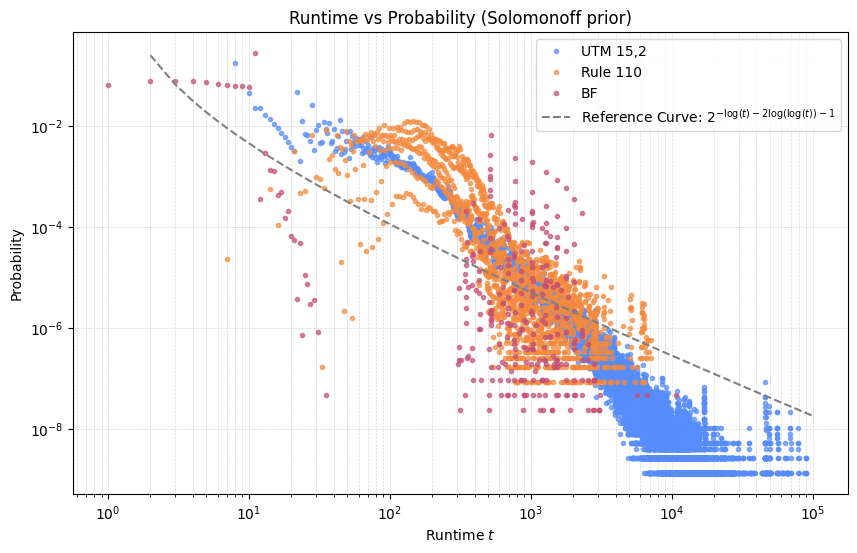

In [171]:
max_runtime = 100_000

# log-log plot of runtimes against probability
utm_total_programs = np.sum(utm_num_runtimes)
utm_probabilities = utm_num_runtimes / utm_total_programs

bf_total_programs = np.sum(bf_num_runtimes)
bf_probabilities = bf_num_runtimes / bf_total_programs

rule110_total_programs = np.sum(rule110_num_runtimes)
rule110_probabilities = rule110_num_runtimes / rule110_total_programs

tag_total_programs = np.sum(tag_num_runtimes)
tag_probabilities = tag_num_runtimes / tag_total_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")
plt.loglog(np.arange(max_runtime), rule110_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Rule 110")
plt.loglog(np.arange(max_runtime), bf_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="BF")
#plt.loglog(np.arange(max_runtime), tag_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="2-Tag")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range[1:]) - 2*np.log2(np.log2(x_range[1:])) - 1)
plt.loglog(x_range[1:], reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 1}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)


# save plot as pdf
plt.savefig("runtime_vs_probability_only_bf.pdf")

plt.show()

# Statistical Test for spikes

In [52]:
from scipy import stats
from scipy.stats import norm
from statsmodels.nonparametric.kernel_regression import KernelReg
from pygam import LinearGAM, s

In [37]:
def test_for_spikes(runtime, p, n_splines=25):
    # 1. Transform to log-log domain and sort by runtime
    log_runtime = np.log(runtime)
    log_p = np.log(p)

    order = np.argsort(log_runtime)
    x = log_runtime[order]
    y = log_p[order]

    # 2. Fit smooth mean using local linear regression or GAM splines
    # (For large n, pygam.LinearGAM or scipy.interpolate.UnivariateSpline is faster than KernelReg)
    gam_mu = LinearGAM(s(0, n_splines=n_splines)).fit(x, y)
    mu_hat = gam_mu.predict(x)
    residuals = y - mu_hat

    # 3. Fit smooth conditional variance
    gam_sigma = LinearGAM(s(0, n_splines=n_splines)).fit(x, np.log(residuals**2 + 1e-12))
    sigma_hat = np.sqrt(np.exp(gam_sigma.predict(x)))

    # 4. Standardized residuals
    z = residuals / sigma_hat

    # 5. Nonparametric check: Lag-1 autocorrelation along sorted runtime
    corr, p_val_corr = stats.pearsonr(z[:-1], z[1:])
    print(f"Lag-1 Serial Correlation: {corr:.4f} (p-value: {p_val_corr})")

    # 6. Cumulative residual cusum test
    cusum = np.cumsum(z) / np.sqrt(len(z))
    max_dev = np.max(np.abs(cusum))
    print(f"Max Cumulative Sum Deviation: {max_dev:.4f}")

    return gam_mu, gam_sigma

Lag-1 Serial Correlation: 0.5632 (p-value: 0.0)
Max Cumulative Sum Deviation: 2.0480
runtime of maximum outliers: [16996 16988 17000 16992 16980 17008 16994 16986 46333 17004]
runtime of minimum outliers: [2884 4924 4516 4290 5184 5216 3396 5252 5312 5320]


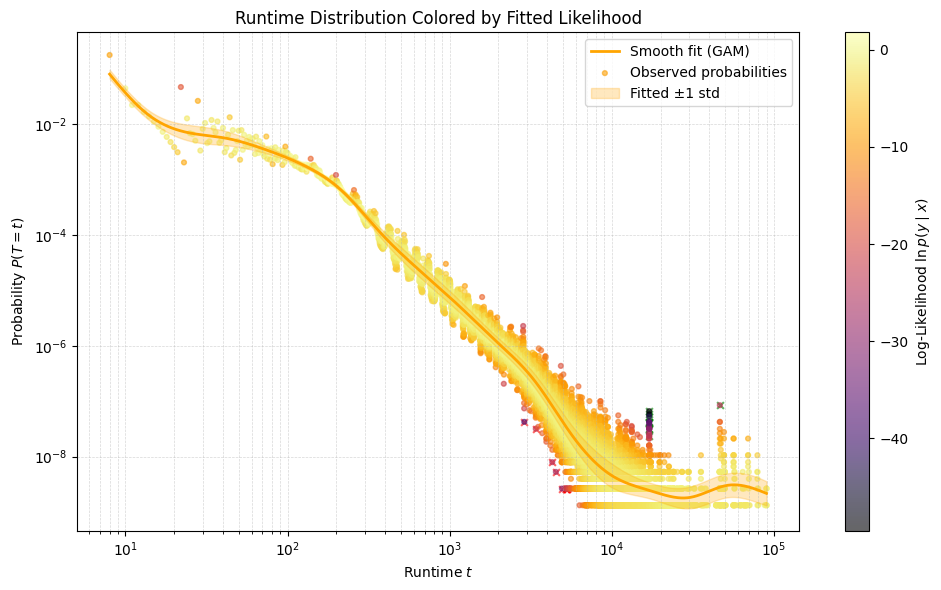

In [180]:
p_dict = {
    "bf": bf_probabilities,
    "rule110": rule110_probabilities,
    "utm": utm_probabilities,
    "tag": tag_probabilities,
}

names_dict = {
    "bf": "BF",
    "rule110": "Rule110",
    "utm": "UTM",
    "tag": "2-Tag"
}

domain = "utm"

runtime = np.arange(max_runtime)
p = p_dict[domain]

filter = p > 0
p = p[filter]
runtime = runtime[filter]

gam_mu, gam_sigma = test_for_spikes(runtime, p, n_splines=20)

# --- 1. Compute fitted params at the observed runtime points ---
log_rt = np.log(runtime)
log_p_obs = np.log(p)

mu_hat = gam_mu.predict(log_rt)
sigma_hat = np.sqrt(np.exp(gam_sigma.predict(log_rt)))

# --- 2. Calculate point-wise likelihood (or log-likelihood) ---
# Log-likelihood under the local Gaussian model N(mu, sigma^2) on log(p):
point_log_lik = norm.logpdf(log_p_obs, loc=mu_hat, scale=sigma_hat)
above_mu = np.sign(log_p_obs - mu_hat) * 0.5 + 0.5

# find local maxima and minima
min_idxs = []
max_idxs = []
for i in range(1, len(log_rt) - 1):
    if (log_p_obs[i-1] < log_p_obs[i]) and (log_p_obs[i+1] < log_p_obs[i]):
        max_idxs.append(i)
    elif (log_p_obs[i-1] > log_p_obs[i]) and (log_p_obs[i+1] > log_p_obs[i]):
        min_idxs.append(i)
min_idxs = np.array(min_idxs)
max_idxs = np.array(max_idxs)

max_lik_sort = np.argsort(point_log_lik[max_idxs] + 1e5 * (1 - above_mu[max_idxs]))
max_idxs = max_idxs[max_lik_sort[:10]]
print(f"runtime of maximum outliers: {runtime[max_idxs]}")

min_lik_sort = np.argsort(point_log_lik[min_idxs] + 1e5 * (0 + above_mu[min_idxs]))
min_idxs = min_idxs[min_lik_sort[:10]]
print(f"runtime of minimum outliers: {runtime[min_idxs]}")


# Alternatively, for normalized likelihood values in [0, 1] relative to the mean:
# relative_lik = np.exp(-0.5 * ((log_p_obs - mu_hat) / sigma_hat)**2)

# --- 3. Grid for curve and confidence band ---
x_plot = np.geomspace(runtime.min(), runtime.max(), 1000)
log_x_plot = np.log(x_plot)

mu_plot = gam_mu.predict(log_x_plot)
sigma_plot = np.sqrt(np.exp(gam_sigma.predict(log_x_plot)))

y_plot = np.exp(mu_plot)
y_lower = np.exp(mu_plot - sigma_plot)
y_upper = np.exp(mu_plot + sigma_plot)

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    runtime[max_idxs],
    p[max_idxs],
    marker='x',
    c='green',
    s=24,
    alpha=0.6,
)

scatter = plt.scatter(
    runtime[min_idxs],
    p[min_idxs],
    marker='x',
    c='red',
    s=24,
    alpha=0.6,
)

# Use plt.scatter so 'c' can map array values through a colormap
scatter = plt.scatter(
    runtime,
    p,
    c=point_log_lik,
    cmap="inferno",
    s=12,
    alpha=0.6,
    label="Observed probabilities",
)



# Smooth curves and bands
plt.plot(x_plot, y_plot, "-", linewidth=2, label="Smooth fit (GAM)", color="orange")
plt.fill_between(
    x_plot, y_lower, y_upper, alpha=0.25, label="Fitted ±1 std", color="orange"
)

# Set log-log scaling explicitly
plt.xscale("log")
plt.yscale("log")

# Add colorbar for likelihood interpretation
cbar = plt.colorbar(scatter)
cbar.set_label("Log-Likelihood $\\ln p(y \\mid x)$")

plt.xlabel("Runtime $t$")
plt.ylabel("Probability $P(T = t)$")
plt.title("Runtime Distribution Colored by Fitted Likelihood")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

KS $p = 1.05e-279$


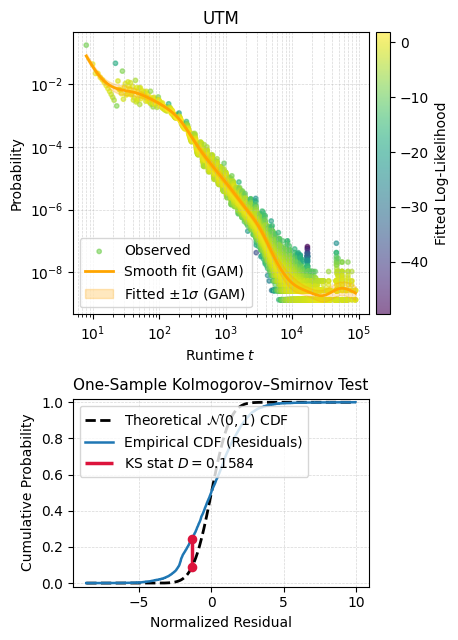

In [181]:
# ---------------------------------------------------------
# 1. Predictions & Point-wise Log-Likelihood
# ---------------------------------------------------------
log_rt = np.log(runtime)
log_p_obs = np.log(p)

mu_hat = gam_mu.predict(log_rt)
sigma_hat = np.sqrt(np.exp(gam_sigma.predict(log_rt)))

# Standardized residuals (z-scores under the model)
z = (log_p_obs - mu_hat) / sigma_hat

# Point-wise log-likelihood
point_log_lik = norm.logpdf(log_p_obs, loc=mu_hat, scale=sigma_hat)

# Smooth curve grid
x_plot = np.geomspace(runtime.min(), runtime.max(), 1000)
log_x_plot = np.log(x_plot)
mu_plot = gam_mu.predict(log_x_plot)
sigma_plot = np.sqrt(np.exp(gam_sigma.predict(log_x_plot)))

y_plot = np.exp(mu_plot)
y_lower = np.exp(mu_plot - sigma_plot)
y_upper = np.exp(mu_plot + sigma_plot)

# ---------------------------------------------------------
# 2. Kolmogorov-Smirnov Calculation
# ---------------------------------------------------------
# Run 1-sample KS test against standard normal N(0, 1)
ks_stat, ks_pval = stats.kstest(z, "norm")

# Sort residuals to construct ECDF
z_sorted = np.sort(z)
n = len(z_sorted)
ecdf_y = np.arange(1, n + 1) / n
ecdf_y_prev = np.arange(0, n) / n  # Lower step for exact supremum distance
cdf_theo = stats.norm.cdf(z_sorted)

# Find exact point of maximal absolute deviation D
diffs_high = np.abs(ecdf_y - cdf_theo)
diffs_low = np.abs(ecdf_y_prev - cdf_theo)
max_idx = np.argmax(np.maximum(diffs_high, diffs_low))

z_max = z_sorted[max_idx]
y_ecdf_max = ecdf_y[max_idx]
y_theo_max = stats.norm.cdf(z_max)

# ---------------------------------------------------------
# 3. Two-Panel Visualization
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), gridspec_kw={"height_ratios": [1.5, 1]}
)

# Panel 1: Runtime distribution + Likelihood coloring
scatter = ax1.scatter(
    runtime,
    p,
    c=point_log_lik,
    cmap="viridis",
    s=10,
    alpha=0.6,
    label="Observed",
    zorder=1,
)
ax1.plot(x_plot, y_plot, "-", linewidth=2, color="orange", label="Smooth fit (GAM)")
ax1.fill_between(
    x_plot, y_lower, y_upper, alpha=0.25, color="orange", label="Fitted $\pm 1\\sigma$ (GAM)"
)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Runtime $t$")
ax1.set_ylabel("Probability")
ax1.set_title(names_dict[domain])
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# 1. Enforce explicit legend order: Observed first, then Smooth fit, then Fitted +-sigma
handles, labels = ax1.get_legend_handles_labels()
desired_order = ["Observed", "Smooth fit (GAM)", "Fitted $\pm 1\\sigma$ (GAM)"]
ordered_handles = [handles[labels.index(name)] for name in desired_order]
ax1.legend(ordered_handles, desired_order, loc="lower left")

# Panel 2: KS Test ECDF vs Theoretical Normal CDF
z_range = np.linspace(min(z_sorted.min(), -4), max(z_sorted.max(), 4), 500)
ax2.plot(
    z_range,
    stats.norm.cdf(z_range),
    "k--",
    linewidth=2,
    label="Theoretical $\\mathcal{N}(0, 1)$ CDF",
)
ax2.step(
    z_sorted,
    ecdf_y,
    where="post",
    color="#1f77b4",
    linewidth=1.8,
    label="Empirical CDF (Residuals)",
)

# Annotate KS statistic (max deviation line)
ax2.vlines(
    x=z_max,
    ymin=min(y_ecdf_max, y_theo_max),
    ymax=max(y_ecdf_max, y_theo_max),
    color="crimson",
    linewidth=2.5,
    label=f"KS stat $D = {ks_stat:.4f}$",
)
ax2.scatter(
    [z_max, z_max],
    [y_ecdf_max, y_theo_max],
    color="crimson",
    s=35,
    zorder=5,
)

ax2.set_xlabel("Normalized Residual")
ax2.set_ylabel("Cumulative Probability")
ax2.set_title("One-Sample Kolmogorov–Smirnov Test", size=11)
ax2.set_ylim(-0.02, 1.02)
ax2.grid(True, ls="--", linewidth=0.5)
ax2.legend(loc="upper left")

# Call tight_layout FIRST so subplots calculate their standard layout
plt.tight_layout()

# Add colorbar to ax1
cbar = fig.colorbar(scatter, ax=ax1, pad=0.02)
cbar.set_label("Fitted Log-Likelihood")

# 2. Match the horizontal bounds of ax2 to ax1 (excluding the colorbar)
pos1 = ax1.get_position()
pos2 = ax2.get_position()
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])

#fig.tight_layout()
fig.savefig(f"spike_test_{domain}.pdf")

print(f"KS $p = {ks_pval:.2e}$")

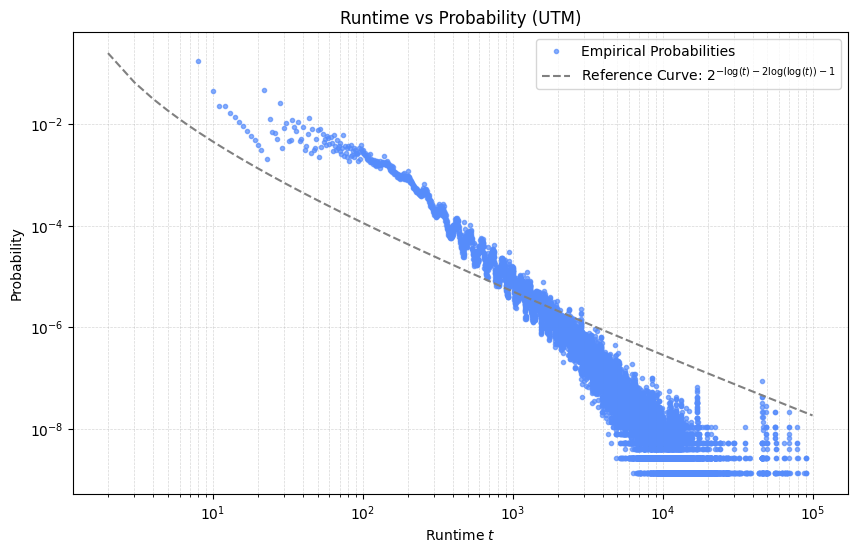

In [182]:
max_runtime = 100_000

# log-log plot of runtimes against probability
utm_total_programs = np.sum(utm_num_runtimes)
utm_probabilities = utm_num_runtimes / utm_total_programs

bf_total_programs = np.sum(bf_num_runtimes)
bf_probabilities = bf_num_runtimes / bf_total_programs

rule110_total_programs = np.sum(rule110_num_runtimes)
rule110_probabilities = rule110_num_runtimes / rule110_total_programs

tag_total_programs = np.sum(tag_num_runtimes)
tag_probabilities = tag_num_runtimes / tag_total_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(runtime, p, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Empirical Probabilities")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range[1:]) - 2*np.log2(np.log2(x_range[1:])) - 1)
plt.loglog(x_range[1:], reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 1}$')
plt.legend()

plt.title(f'Runtime vs Probability ({names_dict[domain]})')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)


# save plot as pdf
plt.savefig(f"runtime_vs_probability_{domain}.pdf")

plt.show()

Observed Lag-1 Serial Correlation: -0.2523 (95% Wild Bootstrap CI: [-0.0544, 0.0321])
Observed KS Statistic D: 0.1738 (Lilliefors/Bootstrap p-value: 0.0000)


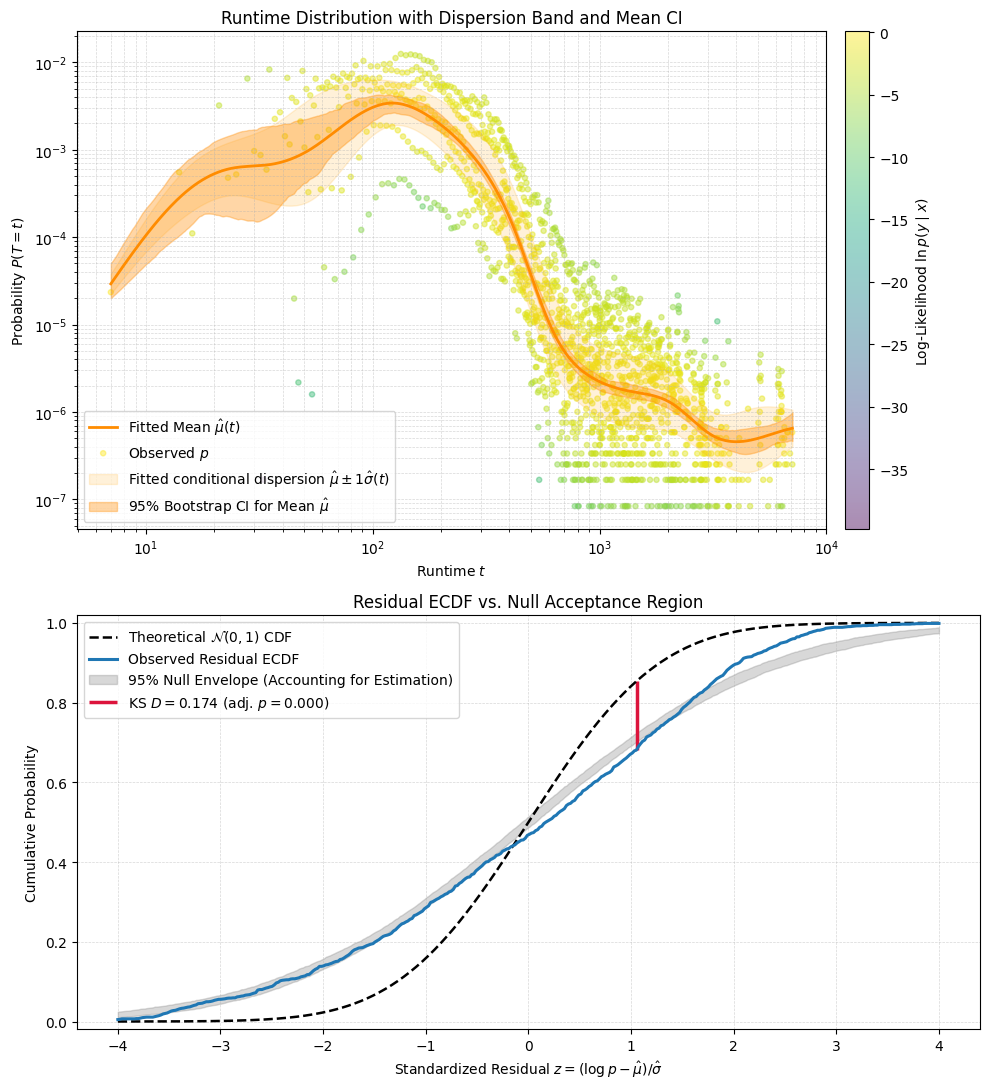

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from pygam import LinearGAM, s
from scipy import stats
from scipy.stats import norm

# ---------------------------------------------------------
# 1. Base Fit & Standardized Residuals
# ---------------------------------------------------------
# Ensure sorted order by runtime for proper lag-1 correlation
order = np.argsort(runtime)
runtime = runtime[order]
p = p[order]

log_rt = np.log(runtime)
log_p = np.log(p)
n = len(log_rt)

# Fit mean and variance GAMs
gam_mu = LinearGAM(s(0, n_splines=20)).fit(log_rt, log_p)
mu_hat = gam_mu.predict(log_rt)
raw_residuals = log_p - mu_hat

gam_sigma = LinearGAM(s(0, n_splines=20)).fit(
    log_rt, np.log(raw_residuals**2 + 1e-12)
)
sigma_hat = np.sqrt(np.exp(gam_sigma.predict(log_rt)))

# Standardized residuals
z_obs = raw_residuals / sigma_hat

# Observed statistics
ks_stat_obs, _ = stats.kstest(z_obs, "norm")
corr_obs, _ = stats.pearsonr(z_obs[:-1], z_obs[1:])

# Evaluation grids
x_grid = np.geomspace(runtime.min(), runtime.max(), 500)
log_x_grid = np.log(x_grid)
mu_grid = gam_mu.predict(log_x_grid)
sigma_grid = np.sqrt(np.exp(gam_sigma.predict(log_x_grid)))

z_eval_grid = np.linspace(-4, 4, 400)
ecdf_obs = np.mean(z_obs[:, None] <= z_eval_grid, axis=0)

# ---------------------------------------------------------
# 2. Bootstrapping (Wild for Mean & Lag-1, Parametric for KS Null)
# ---------------------------------------------------------
B = 250

boot_mu_curves = np.empty((B, len(x_grid)))
boot_corr = np.empty(B)
null_ecdfs = np.empty((B, len(z_eval_grid)))
null_ks_stats = np.empty(B)

# Mammen two-point weights for wild bootstrap
sqrt5 = np.sqrt(5)
v1 = -(sqrt5 - 1) / 2
v2 = (sqrt5 + 1) / 2
prob_v1 = (sqrt5 + 1) / (2 * sqrt5)

for b in range(B):
    # A. Wild Bootstrap (Estimates uncertainty in mu and lag-1 autocorrelation)
    u = np.random.rand(n)
    v = np.where(u < prob_v1, v1, v2)
    log_p_wild = mu_hat + raw_residuals * v

    # Refit mean GAM on wild data
    gam_mu_b = LinearGAM(s(0, n_splines=20)).fit(log_rt, log_p_wild)
    boot_mu_curves[b] = gam_mu_b.predict(log_x_grid)

    # Standardize residuals using the refit mean and base sigma
    res_b = log_p_wild - gam_mu_b.predict(log_rt)
    z_wild = res_b / sigma_hat
    boot_corr[b], _ = stats.pearsonr(z_wild[:-1], z_wild[1:])

    # B. Null Bootstrap for KS test (Simulate data strictly under H0: local normality)
    log_p_null = mu_hat + np.random.normal(0, sigma_hat)

    # Refit models on null data (replicates parameter estimation drag)
    gam_mu_null = LinearGAM(s(0, n_splines=20)).fit(log_rt, log_p_null)
    res_null = log_p_null - gam_mu_null.predict(log_rt)

    gam_sigma_null = LinearGAM(s(0, n_splines=20)).fit(
        log_rt, np.log(res_null**2 + 1e-12)
    )
    sigma_null = np.sqrt(np.exp(gam_sigma_null.predict(log_rt)))

    z_null = res_null / sigma_null
    null_ecdfs[b] = np.mean(z_null[:, None] <= z_eval_grid, axis=0)
    null_ks_stats[b], _ = stats.kstest(z_null, "norm")

# ---------------------------------------------------------
# 3. Confidence Intervals & Statistical Summary
# ---------------------------------------------------------
# 95% CI for the mean curve
mu_ci_lower = np.percentile(boot_mu_curves, 2.5, axis=0)
mu_ci_upper = np.percentile(boot_mu_curves, 97.5, axis=0)

# 95% CI for Lag-1 autocorrelation
corr_ci_lower = np.percentile(boot_corr, 2.5)
corr_ci_upper = np.percentile(boot_corr, 97.5)

# 95% Null envelope for KS ECDF
null_ecdf_lower = np.percentile(null_ecdfs, 2.5, axis=0)
null_ecdf_upper = np.percentile(null_ecdfs, 97.5, axis=0)

# Parameter-adjusted KS p-value (fraction of null D >= observed D)
p_val_ks_adjusted = np.mean(null_ks_stats >= ks_stat_obs)

print(
    f"Observed Lag-1 Serial Correlation: {corr_obs:.4f} "
    f"(95% Wild Bootstrap CI: [{corr_ci_lower:.4f}, {corr_ci_upper:.4f}])"
)
print(
    f"Observed KS Statistic D: {ks_stat_obs:.4f} "
    f"(Lilliefors/Bootstrap p-value: {p_val_ks_adjusted:.4f})"
)

# ---------------------------------------------------------
# 4. Two-Panel Visualization
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 11), gridspec_kw={"height_ratios": [1.2, 1]}
)

# --- Panel 1: Data, Fitted Mean CI, and Fitted Dispersion Band ---
point_log_lik = norm.logpdf(log_p, loc=mu_hat, scale=sigma_hat)
scatter = ax1.scatter(
    runtime,
    p,
    c=point_log_lik,
    cmap="viridis",
    s=14,
    alpha=0.45,
    label="Observed $p$",
)

# Fitted conditional dispersion band from gam_sigma (no bootstrap)
y_disp_lower = np.exp(mu_grid - sigma_grid)
y_disp_upper = np.exp(mu_grid + sigma_grid)
ax1.fill_between(
    x_grid,
    y_disp_lower,
    y_disp_upper,
    color="orange",
    alpha=0.15,
    label="Fitted conditional dispersion $\\hat{\\mu} \\pm 1\\hat{\\sigma}(t)$",
)

# Fitted mean + Bootstrap CI for the mean
ax1.plot(
    x_grid,
    np.exp(mu_grid),
    color="darkorange",
    linewidth=2,
    label="Fitted Mean $\\hat{\\mu}(t)$",
)
ax1.fill_between(
    x_grid,
    np.exp(mu_ci_lower),
    np.exp(mu_ci_upper),
    color="darkorange",
    alpha=0.35,
    label="95% Bootstrap CI for Mean $\\hat{\\mu}$",
)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Runtime $t$")
ax1.set_ylabel("Probability $P(T = t)$")
ax1.set_title("Runtime Distribution with Dispersion Band and Mean CI")
ax1.grid(True, which="both", ls="--", linewidth=0.5)
ax1.legend(loc="lower left")

cbar = fig.colorbar(scatter, ax=ax1, pad=0.02)
cbar.set_label("Log-Likelihood $\\ln p(y \\mid x)$")

# --- Panel 2: ECDF against the Bootstrap Null Acceptance Region ---
ax2.plot(
    z_eval_grid,
    stats.norm.cdf(z_eval_grid),
    "k--",
    linewidth=1.8,
    label="Theoretical $\\mathcal{N}(0, 1)$ CDF",
)

# Null acceptance region: where ECDFs are expected to fall under H0
ax2.fill_between(
    z_eval_grid,
    null_ecdf_lower,
    null_ecdf_upper,
    color="gray",
    alpha=0.3,
    label="95% Null Envelope (Accounting for Estimation)",
)

# Observed ECDF
ax2.plot(
    z_eval_grid,
    ecdf_obs,
    color="#1f77b4",
    linewidth=2.2,
    label="Observed Residual ECDF",
)

# KS statistic line at maximum divergence
z_sorted = np.sort(z_obs)
ecdf_steps = np.arange(1, n + 1) / n
diffs = np.abs(ecdf_steps - stats.norm.cdf(z_sorted))
max_idx = np.argmax(diffs)
z_max = z_sorted[max_idx]

ax2.vlines(
    x=z_max,
    ymin=min(ecdf_steps[max_idx], stats.norm.cdf(z_max)),
    ymax=max(ecdf_steps[max_idx], stats.norm.cdf(z_max)),
    color="crimson",
    linewidth=2.5,
    label=f"KS $D = {ks_stat_obs:.3f}$ (adj. $p = {p_val_ks_adjusted:.3f}$)",
)

ax2.set_xlabel("Standardized Residual $z = (\\log p - \\hat{\\mu}) / \\hat{\\sigma}$")
ax2.set_ylabel("Cumulative Probability")
ax2.set_title("Residual ECDF vs. Null Acceptance Region")
ax2.set_ylim(-0.02, 1.02)
ax2.grid(True, ls="--", linewidth=0.5)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range[1:]) - 2*np.log2(np.log2(x_range[1:])) - 2)
plt.loglog(x_range[1:], reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
def binary_representation(n, encoding_level=1):
    """Return the binary representation of an integer n as a boolean array of bits."""
    if n == 0:
        return np.array([False])
    bits = []

    current_level = 1
    current_n = n
    while current_level <= encoding_level:
        current_bits = []
        while current_n:
            current_bits.append(bool(current_n & 1))
            current_n >>= 1
        if current_level == encoding_level:
            bits = [b for b in current_bits[::-1] for _ in range(2)] + [0] + bits
            break
        else:
            bits = current_bits[::-1] + bits
            current_n = len(current_bits)
            current_level += 1

    return np.array(bits, dtype=bool)

In [ ]:
binary_representation(1024, encoding_level=2).astype(int)

In [ ]:
def description_length(n):
    p_one = np.mean(n)
    description_length = 0
    for bit in n:
        if bit:
            description_length += -np.log2(p_one) if p_one > 0 else 0
        else:
            description_length += -np.log2(1 - p_one) if p_one < 1 else 0

    return description_length


def lz76_kolmogorov_estimate(n: np.ndarray) -> dict:
    """
    Estimates the Kolmogorov complexity (in bits) of a 1D boolean array
    by tracking the exact history pointers and innovation bits.
    """
    length = len(n)
    if length == 0:
        return {"phrases": 0, "bits_exact": 0, "bits_asymptotic": 0.0, "normalized_complexity": 0.0}

    b = n.astype(np.uint8).tobytes()

    phrases = 1
    start = 0
    end = 1
    total_bits = 1  # First bit is explicit

    while end <= length:
        sub = b[start:end]
        history = b[0:end - 1]

        match_idx = history.find(sub)

        if match_idx != -1 and end < length:
            end += 1
        else:
            phrases += 1
            # Pointer to history location: log2(history length) + 1 bit for the new symbol
            if start > 0:
                pointer_bits = math.ceil(math.log2(start + 1))
                total_bits += pointer_bits + 1  # pointer + next bit
            else:
                total_bits += 1

            start = end
            end = start + 1

    # Theoretical asymptotic estimate: c(n) * log2(n)
    asymptotic_bits = phrases * (math.log2(length) if length > 1 else 1)

    # Normalized complexity against a random string: c(n) / (n / log2(n))
    random_bound = length / math.log2(length) if length > 1 else 1
    normalized_complexity = min(1.0, phrases / random_bound)

    return {
        "phrases": phrases,
        "bits_exact": total_bits,
        "bits_asymptotic": asymptotic_bits,
        "normalized_complexity": normalized_complexity
    }

In [ ]:
description_length(binary_representation(2048, 2))

In [ ]:
br1 = [binary_representation(i, 1) for i in x_range]
br2 = [binary_representation(i, 2) for i in x_range]
br3 = [binary_representation(i, 3) for i in x_range]

length_l1 = np.array([float(len(b)) for b in br1])
length_l2 = np.array([float(len(b)) for b in br2])
length_l3 = np.array([float(len(b)) for b in br3])

description_lengths_l1 = np.array([description_length(b) for b in br1])
description_lengths_l2 = np.array([description_length(b) for b in br2])
description_lengths_l3 = np.array([description_length(b) for b in br3])

lz_lengths_l1 = np.array([float(lz76_kolmogorov_estimate(b)["bits_exact"]) for b in br1])
lz_lengths_l2 = np.array([float(lz76_kolmogorov_estimate(b)["bits_exact"]) for b in br2])
lz_lengths_l3 = np.array([float(lz76_kolmogorov_estimate(b)["bits_exact"]) for b in br3])

In [ ]:
def compute_dsl_lengths(
    limit: int = 100_000,
    c_double: int = 1,
    c_add_sub: int = 3,
    c_halt: int = 2,
) -> list[int]:
    """Computes the minimal DSL prefix-free description length (in bits)

    for all integers from 1 to limit (inclusive).

    Returns a 1-indexed list of length (limit + 1), where result[n] is the
    description length in bits for integer n. Index 0 is set to 0.
    """
    # cost_ops[n] stores the operational cost from 1 to n (excluding HALT)
    cost_ops = [0] * (limit + 1)
    cost_ops[1] = 0

    c_odd_step = c_double + c_add_sub  # 1 + 3 = 4

    for i in range(2, limit + 1):
        if i % 2 == 0:
            cost_ops[i] = cost_ops[i >> 1] + c_double
        else:
            k = i >> 1
            # i = 2k + 1: transition is either *2, +1 from k, or *2, -1 from k + 1
            cost_ops[i] = c_odd_step + (
                cost_ops[k] if cost_ops[k] < cost_ops[k + 1] else cost_ops[k + 1]
            )

    # Add HALT code length to obtain complete prefix-free codeword lengths
    return [cost + c_halt if i >= 1 else 0 for i, cost in enumerate(cost_ops)]


# --- Execution and Verification ---
dsl_lengths = compute_dsl_lengths(100_000)

# Sanity checks
assert dsl_lengths[1] == 2  # HALT only
assert dsl_lengths[3] == 6  # *2 +1 HALT
assert dsl_lengths[11] == 11  # *2 *2 +1 *2 +1 HALT
assert dsl_lengths[255] == 13  # (*2)^8 -1 HALT
assert dsl_lengths[65535] == 21  # (*2)^16 -1 HALT

print(f"Computed {len(dsl_lengths) - 1:,} values.")
print(f"Sample - n=100,000: {dsl_lengths[100_000]} bits")
print(f"Average length (1 to 100,000): {sum(dsl_lengths[1:]) / 100_000:.2f} bits")
print(f"Maximum length (1 to 100,000): {max(dsl_lengths)} bits")

In [ ]:
len(dsl_lengths)

In [ ]:
# plot the DSL lengths and length_l2 against n

plt.figure(figsize=(10, 6))
plt.plot(x_range, dsl_lengths[1:-1], label="DSL Lengths (Prefix-Free)")
plt.plot(x_range, length_l2, label="Binary Representation Lengths (Level 2)")
plt.plot(x_range, [np.log2(r) + 2*np.log2(np.log2(r)) + 1 for r in x_range], label="Binary Representation Lengths (Level 2), continuous")
plt.plot(x_range, length_l1, label="Binary Representation Lengths (Level 1)")
plt.title("Description Lengths vs n")
plt.xlabel("Integer n")
plt.ylabel("Description Length (bits)")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

# Measure Correlation

In [ ]:
import pandas as pd
import seaborn as sns
from pingouin import partial_corr

In [ ]:
# dictionary from runtime_probs
runtime_probs = {
    "tag": tag_probabilities_weighted,
    "utm": utm_probabilities_weighted,
    "rule110": rule110_probabilities_weighted,
}

# dictionary from runtime description lengths
runtime_dict = {
    "lz_l1": lz_lengths_l1,
    "lz_l2": lz_lengths_l2,
    "shannon_l1": description_lengths_l1,
    "shannon_l2": description_lengths_l2,
    "length_l1": length_l1,
    "length_l2": length_l2,
    "dsl_lengths": np.array(dsl_lengths[1:-1]).astype(float),  # skip index 0
}

In [ ]:
domain_runtimes = {}
for domain, runtime_prob in runtime_probs.items():
    runtimes = [i for i, p in enumerate(runtime_prob) if p > 0.]
    probabilities = [p for i, p in enumerate(runtime_prob) if p > 0.]
    # create dataframe for this domain
    df = pd.DataFrame({
        "runtime": runtimes,
        "probability": probabilities
    })
    df["continuous_runtime"] = [2 ** (-np.log2(r) - 2*np.log2(np.log2(r)) - 1) for r in runtimes]
    for desc_name, desc_lengths in runtime_dict.items():
        df[desc_name] = [2 ** (-desc_lengths[i-1]) for i in runtimes]
    domain_runtimes[domain] = df

In [ ]:
domain_runtimes["tag"]

In [ ]:
# measure correlation between description lengths and runtimes for each domain
correlation_results = {}
for domain, df in domain_runtimes.items():
    correlation_matrix = df.corr()
    correlation_results[domain] = correlation_matrix

# plot correlation matrices
for domain, corr_matrix in correlation_results.items():
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(f"Correlation Matrix for {domain}")
    plt.show()

In [ ]:
# add the logarithms of the description lengths and runtimes to the dataframes
for domain, df in domain_runtimes.items():
    for desc_name in ["probability", "continuous_runtime", "lz_l1", "lz_l2", "shannon_l1", "shannon_l2", "length_l1", "length_l2", "dsl_lengths"]:
        df[f"log_{desc_name}"] = np.log2(df[desc_name])

In [ ]:
# for each domain, measure partial correlation between probability and description lengths, controlling for length_l1
partial_correlation_results = {}
for domain, df in domain_runtimes.items():
    partial_corr_results = {}
    for desc_name in ["log_lz_l1", "log_lz_l2", "log_shannon_l1", "log_shannon_l2", "log_dsl_lengths"]:
        pcorr = partial_corr(data=df, x=desc_name, y="log_probability", covar="log_continuous_runtime", method="pearson")
        partial_corr_results[desc_name] = pcorr
    partial_correlation_results[domain] = partial_corr_results

# print results for log_dsl_lengths
for domain, pcorr_results in partial_correlation_results.items():
    print(f"Partial correlation results for {domain}:")
    print(pcorr_results['log_dsl_lengths'])
    print()

In [ ]:
# plot partial correlation results
for domain, pcorr_results in partial_correlation_results.items():
    plt.figure(figsize=(10, 6))
    desc_names = list(pcorr_results.keys())
    pcorr_values = [pcorr_results[desc_name]["r"].values[0] for desc_name in desc_names]
    plt.bar(desc_names, pcorr_values)
    plt.title(f"Partial Correlation of Description Lengths with Probability (controlling for length_l1) for {domain}")
    plt.ylabel("Partial Correlation Coefficient")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
domain_runtimes["tag"]["dsl_lengths"]

In [ ]:
# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(range(len(dsl_lengths)),
           2**(-np.array(dsl_lengths).astype(float)),
           color='grey', linestyle='-', alpha=0.7, label="DSL Reference")

plt.loglog(np.array(domain_runtimes["tag"]["runtime"]),
           np.array(domain_runtimes["tag"]["probability"]),
           marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Tag System")

plt.loglog(np.array(domain_runtimes["rule110"]["runtime"]),
           np.array(domain_runtimes["rule110"]["probability"]),
           marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Rule 110")

plt.loglog(np.array(domain_runtimes["utm"]["runtime"]),
           np.array(domain_runtimes["utm"]["probability"]),
           marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 UTM")

plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.ylim(1e-12, 1e0)
# save plot as pdf
#plt.savefig("runtime_vs_probability.pdf")

plt.show()

# Correlation plots

In [ ]:
# for utm, plot log probabilities against log description lengths
plt.figure(figsize=(10, 6))
plt.scatter(np.log2(domain_runtimes["utm"]["dsl_lengths"]), np.log2(domain_runtimes["utm"]["probability"]), alpha=0.5, label="LZ l1")
plt.scatter(np.log2(domain_runtimes["utm"]["continuous_runtime"]), np.log2(domain_runtimes["utm"]["probability"]), alpha=0.5, label="LZ l1")

plt.title('Description Length vs Probability')
plt.xlabel('Log Description Length (bits)')
plt.ylabel('Log Probability')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
X

In [ ]:
x

In [ ]:
# control for continuous runtime by fitting a polynomial regression (3rd degree) and plotting the residuals
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

domain = "utm"

x = np.log2(domain_runtimes[domain]["continuous_runtime"]).values
y = np.log2(domain_runtimes[domain]["probability"]).values

poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x[:, None])

model = LinearRegression()
model.fit(x_poly, y)

y_pred = model.predict(x_poly)
prob_residuals = y - y_pred

dsl = np.log2(domain_runtimes[domain]["shannon_l2"]).values

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.scatter(dsl, prob_residuals, alpha=0.5)
plt.title('Residuals vs Description Length')
plt.xlabel('Log Description Length')
plt.ylabel('Residuals')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
# plot description lengths against runtimes
plt.figure(figsize=(10, 6))

plt.loglog(x_range, 2**(-lz_lengths_l1), label='LZ l1')
plt.loglog(x_range, 2**(-lz_lengths_l2), label='LZ l2')

plt.loglog(x_range, 2**(-description_lengths_l1), label='Shannon l1')
plt.loglog(x_range, 2**(-description_lengths_l2), label='Shannon l2')
#plt.loglog(x_range, 2**(-description_lengths_l3), label='Shannon l3')


plt.loglog(x_range, 2**(-length_l1), label='Length l1')
plt.loglog(x_range, 2**(-length_l2), label='Length l2')
#plt.loglog(x_range, 2**(-length_l3), label='Length l3')

plt.title('Description Length vs Runtime')
plt.xlabel('Runtime $t$')
plt.ylabel('Description Length (bits)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
plt.loglog(x_range, 2**(-lz_lengths_l2), color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
# calculate pareto front of utm_runtimes
pareto_frontier = []
current_max_prob = 0

for i in reversed(range(1, max_runtime)):
    runtime = i
    probability = utm_probabilities_weighted[i]
    if probability > current_max_prob:
        pareto_frontier.append((runtime, probability))
        current_max_prob = probability


In [ ]:
print(pareto_frontier)

In [ ]:
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")

# pareto frontier points in red
plt.loglog(np.array([p[0] for p in pareto_frontier]), np.array([p[1] for p in pareto_frontier]), marker='o', linestyle='None', markersize=5, alpha=0.7, color='red', label="Pareto Frontier")


x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
plt.loglog(x_range, 2**(-description_lengths), color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.loglog(np.array([p[0] for p in pareto_frontier]), np.array([2**(-description_lengths[p[0]-1]) for p in pareto_frontier]), marker='o', linestyle='None', markersize=5, alpha=0.7, color='green', label="Pareto Frontier")

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [ ]:
print(f"average description length: {np.mean(description_lengths)}")

In [ ]:
pareto_description_lengths = np.array([description_length(binary_representation(p[0])) for p in pareto_frontier])
print(f"average description length of pareto frontier: {np.mean(pareto_description_lengths)}")